In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:


import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Dropout,GlobalAveragePooling2D
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

In [2]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
DATASET_PATH = r"PlantVillage Dataset/color"

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [3]:
NUM_CLASSES = train_data.num_classes

In [7]:
base_model = ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))

base_model.traniable = False # Freeze ResNet weights

In [8]:
print(base_model.trainable)

True


In [29]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu", kernel_regularizer=L2(0.001))(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [30]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,854,886 (91.00 MB)

 Trainable params: 23,801,766 (90.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [31]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history = model.fit(train_data,
                   validation_data=val_data,
                   epochs=10,
                   callbacks=[early_stop])
history

Epoch 1/10


I0000 00:00:1769500581.966543     236 service.cc:152] XLA service 0x7da034014ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769500581.966582     236 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769500581.966587     236 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769500587.725633     236 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769500611.769723     236 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 552s 362ms/step - accuracy: 0.8553 - loss: 0.7922 - val_accuracy: 0.9641 - val_loss: 0.3493
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 421s 310ms/step - accuracy: 0.9837 - loss: 0.2503 - val_accuracy: 0.9778 - val_loss: 0.2330
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 420s 310ms/step - accuracy: 0.9884 - loss: 0.1912 - val_accuracy: 0.9729 - val_loss: 0.2388
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 420s 309ms/step - accuracy: 0.9908 - loss: 0.1470 - val_accuracy: 0.9899 - val_loss: 0.1327
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 420s 309ms/step - accuracy: 0.9933 - loss: 0.1107 - val_accuracy: 0.9944 - val_loss: 0.0879
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 421s 310ms/step - accuracy: 0.9950 - loss: 0.0836 - val_accuracy: 0.9912 - val_loss: 0.0770
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 420s 309ms/step - accuracy: 0.9930 - loss: 0.0720 - val_accuracy: 0.9912 - val_loss: 0.0744
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 420s 310ms/step - accuracy: 0.9

In [ ]:
### Model Save

In [32]:
model.save("resnet50_plantvillage.h5")

In [4]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

NameError: name 'model' is not defined

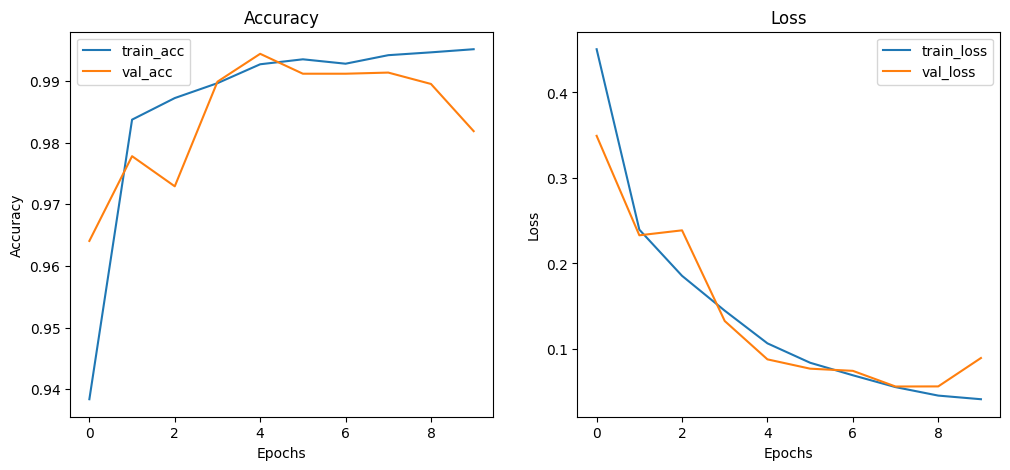

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

Y_pred = model.predict(val_data)

y_pred = np.argmax(Y_pred,axis=1)
print("Confusion Matrix\n\n",confusion_matrix(val_data.classes,y_pred))
print()
print(classification_report(val_data.classes, y_pred, target_names=val_data.class_indices.keys()))

340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step
Confusion Matrix

 [[  3   1   0 ...  13   1   4]
 [  2   1   0 ...  10   2   2]
 [  0   0   0 ...   3   0   2]
 ...
 [ 10  15   9 ... 115  10  32]
 [  1   0   0 ...  10   0   2]
 [  3   1   2 ...  31   2   8]]

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.02      0.02      0.02       126
                                 Apple___Black_rot       0.01      0.01      0.01       124
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                                   Apple___healthy       0.03      0.03      0.03       329
                               Blueberry___healthy       0.02      0.02      0.02       300
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       210
                 Cherry_(including_sour)___healthy       0.01      0.01      0.01       170
Corn_(ma

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


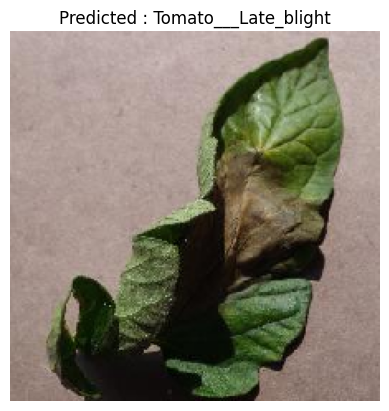

Apple___Apple_scab : 0.0000
Apple___Black_rot : 0.0000
Apple___Cedar_apple_rust : 0.0000
Apple___healthy : 0.0000
Blueberry___healthy : 0.0000
Cherry_(including_sour)___Powdery_mildew : 0.0000
Cherry_(including_sour)___healthy : 0.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 0.0000
Corn_(maize)___Common_rust_ : 0.0000
Corn_(maize)___Northern_Leaf_Blight : 0.0000
Corn_(maize)___healthy : 0.0000
Grape___Black_rot : 0.0000
Grape___Esca_(Black_Measles) : 0.0000
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 0.0000
Grape___healthy : 0.0000
Orange___Haunglongbing_(Citrus_greening) : 0.0000
Peach___Bacterial_spot : 0.0000
Peach___healthy : 0.0000
Pepper,_bell___Bacterial_spot : 0.0000
Pepper,_bell___healthy : 0.0000
Potato___Early_blight : 0.0000
Potato___Late_blight : 0.0000
Potato___healthy : 0.0000
Raspberry___healthy : 0.0000
Soybean___healthy : 0.0000
Squash___Powdery_mildew : 0.0000
Strawberry___Leaf_scorch : 0.0000
Strawberry___healthy : 0.0000
Tomato___Bacterial_spot : 0.00

In [60]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

# Use the class labels from your training generator
class_labels = list(train_data.class_indices.keys())

# path of image
img_path = "/kaggle/input/plantvillage-dataset/color/Tomato___Late_blight/0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG"

# load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# make prediction
predict = model.predict(img_array)
predict_class = class_labels[np.argmax(predict)]

# show image with predicted label
plt.imshow(img)
plt.title(f"Predicted : {predict_class}")
plt.axis('off')
plt.show()

# print confidence for each class
for i, class_name in enumerate(class_labels):
    print(f"{class_name} : {predict[0][i]:.4f}")


In [5]:
#load model
from tensorflow.keras.models import load_model
model = load_model("resnet50_plantvillage.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


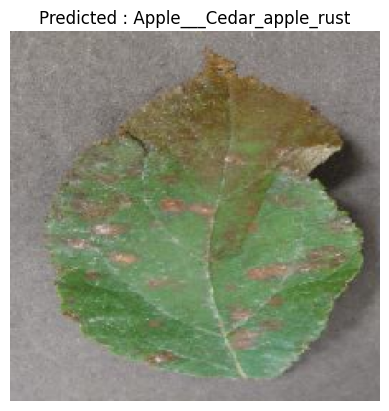

Apple___Apple_scab : 0.0000
Apple___Black_rot : 0.0000
Apple___Cedar_apple_rust : 1.0000
Apple___healthy : 0.0000
Blueberry___healthy : 0.0000
Cherry_(including_sour)___Powdery_mildew : 0.0000
Cherry_(including_sour)___healthy : 0.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 0.0000
Corn_(maize)___Common_rust_ : 0.0000
Corn_(maize)___Northern_Leaf_Blight : 0.0000
Corn_(maize)___healthy : 0.0000
Grape___Black_rot : 0.0000
Grape___Esca_(Black_Measles) : 0.0000
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 0.0000
Grape___healthy : 0.0000
Orange___Haunglongbing_(Citrus_greening) : 0.0000
Peach___Bacterial_spot : 0.0000
Peach___healthy : 0.0000
Pepper,_bell___Bacterial_spot : 0.0000
Pepper,_bell___healthy : 0.0000
Potato___Early_blight : 0.0000
Potato___Late_blight : 0.0000
Potato___healthy : 0.0000
Raspberry___healthy : 0.0000
Soybean___healthy : 0.0000
Squash___Powdery_mildew : 0.0000
Strawberry___Leaf_scorch : 0.0000
Strawberry___healthy : 0.0000
Tomato___Bacterial_spot : 0.00

In [11]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

# Use the class labels from your training generator
class_labels = list(train_data.class_indices.keys())

# path of image
img_path = r"E:\Work\Plant_disease_detection_DL\plantvillage dataset\color\Apple___Cedar_apple_rust\1e099d8e-b40c-4cf3-bb52-4e77b5a2dc69___FREC_C.Rust 0155.JPG"

# load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# make prediction
predict = model.predict(img_array)
predict_class = class_labels[np.argmax(predict)]

# show image with predicted label
plt.imshow(img)
plt.title(f"Predicted : {predict_class}")
plt.axis('off')
plt.show()

# print confidence for each class
for i, class_name in enumerate(class_labels):
    print(f"{class_name} : {predict[0][i]:.4f}")


In [9]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if isinstance(predictions, list):
            predictions = predictions[0]

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()


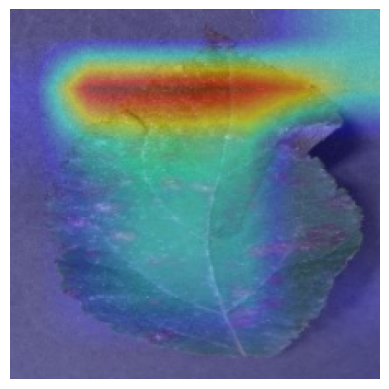

In [ ]:
img_path = r"E:\Work\Plant_disease_detection_DL\plantvillage dataset\color\Apple___Cedar_apple_rust\1e099d8e-b40c-4cf3-bb52-4e77b5a2dc69___FREC_C.Rust 0155.JPG"
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if isinstance(predictions, list):
            predictions = predictions[0]

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()


heatmap = make_gradcam_heatmap(
    img_array, model, last_conv_layer_name="conv5_block3_out"
)

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
Red/Yellow -> region the model use most for prediction
Blue -> less important region